In [203]:
from itertools import accumulate
from random import random, sample, seed
from collections.abc import Sequence
from icecream import ic
from matplotlib import pyplot as plt

In [204]:
N = 100
seed(42)

In [205]:
OBJECTS = {n for n in range(N)}
SETS = tuple(frozenset(sample(range(N), k=s+1)) for s in range(N))
COSTS = tuple(10*random()+(s*random())**2 for s in range(N))

In [206]:
SETS

(frozenset({81}),
 frozenset({3, 14}),
 frozenset({31, 35, 94}),
 frozenset({13, 17, 28, 94}),
 frozenset({11, 69, 75, 86, 94}),
 frozenset({3, 4, 11, 27, 29, 54}),
 frozenset({3, 25, 64, 71, 77, 83, 91}),
 frozenset({0, 28, 35, 53, 57, 69, 75, 89}),
 frozenset({13, 19, 20, 27, 35, 43, 54, 89, 97}),
 frozenset({5, 11, 12, 33, 44, 45, 48, 58, 77, 93}),
 frozenset({10, 15, 24, 37, 46, 48, 68, 70, 73, 79, 80}),
 frozenset({5, 8, 10, 12, 29, 35, 37, 48, 58, 84, 90, 98}),
 frozenset({9, 20, 26, 34, 45, 46, 47, 77, 81, 82, 85, 87, 89}),
 frozenset({20, 21, 28, 31, 34, 41, 48, 59, 68, 71, 81, 87, 88, 93}),
 frozenset({4, 7, 8, 27, 29, 34, 40, 50, 51, 63, 72, 83, 91, 98, 99}),
 frozenset({17, 18, 28, 31, 33, 46, 51, 54, 58, 63, 65, 68, 71, 74, 82, 95}),
 frozenset({6, 8, 11, 14, 19, 20, 32, 48, 49, 54, 59, 67, 70, 76, 80, 87, 96}),
 frozenset({0,
            1,
            14,
            20,
            33,
            34,
            37,
            43,
            55,
            58,
      

In [207]:
COSTS

(4.592252352600417,
 0.8781540028602645,
 9.187979790659753,
 6.216025758599826,
 4.995588413773193,
 10.989939661866423,
 16.488832269389196,
 25.50807754610846,
 42.75798470947266,
 45.64616550829454,
 86.85315710686916,
 75.98441731014677,
 4.091081178832935,
 40.02645200665773,
 89.51593230871411,
 68.77214415426283,
 40.49986227580574,
 94.0434376779207,
 16.326857050844392,
 308.462326028912,
 220.71590644467707,
 401.2857415735966,
 154.656814379813,
 1.2457349090423857,
 172.1611670758956,
 67.49273034233329,
 559.3666980581611,
 127.57535792158977,
 212.42416255098664,
 42.6060459299498,
 42.33389384242443,
 616.3309893281742,
 750.7802304680351,
 1085.9727422602853,
 353.87629973951186,
 8.46525950454405,
 683.2998063986909,
 154.72584618593893,
 621.6892837098512,
 584.7599435484658,
 170.58182895405685,
 643.0813632215439,
 605.0297113108663,
 251.30527422209866,
 358.3171550593605,
 122.76777147337052,
 1160.3613756439586,
 1563.4401087604358,
 1239.1650292178592,
 523.141

# Solution: array of bools

In [208]:
def fitness_aob(solution: Sequence[bool]) -> float:
    weight = sum(COSTS[n] for n in range(N) if solution[n])
    check = frozenset().union(*(SETS[n] for n in range(N) if solution[n]))
    # removed the assert in order to allow partial solutions
    #assert check == frozenset(range(N))
    if check != frozenset(range(N)):
        # penalize incomplete solutions
        weight += 1000 * (N - len(check))
    return -weight

In [209]:
# initial professor sol
# sol = tuple(sample([True, False], k=N, counts=(N,N)))

# list solution (easier to modify)
sol = list(sample([True, False], k=N, counts=(N,N)))

ic(sol)

fitness_aob(sol)

ic| sol: [True,
          True,
          False,
          False,
          True,
          True,
          False,
          False,
          True,
          False,
          True,
          True,
          True,
          True,
          True,
          False,
          False,
          False,
          False,
          False,
          True,
          False,
          True,
          True,
          True,
          False,
          False,
          False,
          False,
          True,
          True,
          False,
          False,
          True,
          False,
          False,
          False,
          False,
          True,
          False,
          True,
          False,
          False,
          False,
          True,
          True,
          True,
          True,
          True,
          True,
          False,
          True,
          False,
          False,
          False,
          True,
          True,
          True,
          False,
          True,
          

-45970.974980840256

# Solution: set of sets

In [210]:
XCOSTS = {SETS[i]: COSTS[i] for i in range(N)}

In [211]:
def fitness_sos(solution: set[frozenset]) -> float:
    weight = sum(XCOSTS[s] for s in solution)
    check = frozenset().union(*solution)
    assert check == frozenset(range(N))
    return -weight

In [212]:
solution = set(sample(SETS, k=5))

ic(solution)

fitness_sos(solution)

ic| solution: {frozenset({81}),
               frozenset({0,
                          1,
                          2,
                          3,
                          4,
                          5,
                          6,
                          7,
                          9,
                          10,
                          11,
                          12,
                          13,
                          14,
                          15,
                          16,
                          17,
                          18,
                          19,
                          20,
                          21,
                          22,
                          23,
                          24,
                          25,
                          26,
                          27,
                          28,
                          29,
                          30,
                          31,
                          33,
                 

-3453.527351988569

In [213]:
def evaluate(solution):
    return sum(COSTS[s] for s in solution)

# Bool solution: implementation

In [ ]:
# Simple tweak
# Randomly chooses a set to flip
# Amount of flips is randomized as well, with the average being 4 flips
def tweak(solution):
    while random() < 0.66:
        index = sample(range(N), k=1)[0]
        solution[index] = not solution[index]
    return solution

# old tweak (continue modifying until solution is valid)
# made because of the original assert in the fitness function
def old_tweak(solution: Sequence[bool]) -> Sequence[bool]:
    # Switch an element
    index = sample(range(N), k=1)[0]
    solution[index] = not solution[index]
    check = frozenset.union(*(SETS[n] for n in range(N) if solution[n]))
    while check != frozenset(range(N)):
        index = sample(range(N), k=1)[0]
        solution[index] = not solution[index]
        check = frozenset.union(*(SETS[n] for n in range(N) if solution[n]))
    return solution

history = [fitness_aob(sol)]  # initial solution evaluation
no_improvements = 0
sol = list(sample([True, False], k=N, counts=(N,N)))
best_sol = sol.copy()

MAX_NO_IMPROVEMENTS = 100
# standard hill climbing
# 2.000 steps, with a restart if 100 steps yield no improvements
for _ in range(2000):
    new_sol = tweak(sol.copy())
    new_fitness = fitness_aob(new_sol)
    history.append(new_fitness)
    if new_fitness > fitness_aob(sol):
        # if new solution is better than the best
        if new_fitness > fitness_aob(best_sol):
            best_sol = new_sol.copy()
        sol = new_sol.copy()
        no_improvements = 0
    else:
        no_improvements += 1
        # Restart from a random point
    if no_improvements >= MAX_NO_IMPROVEMENTS:
        sol = list(sample([True, False], k=N, counts=(N,N)))
        no_improvements = 0

# Note about results: The restarts prove useless in this case,
# but I will keep them as an example on how to use them.

ic(fitness_aob(best_sol), best_sol, history)

ic| fitness_aob(best_sol): -74.85258204885098
    best_sol: [True,
               False,
               False,
               False,
               False,
               False,
               True,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               True,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
           

(-74.85258204885098,
 [True,
  False,
  False,
  False,
  False,
  False,
  True,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  True,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  True],
 [-45970.974980840256,
  -54037.35856991845,
  -54045.82382942299,
  -58756.684810

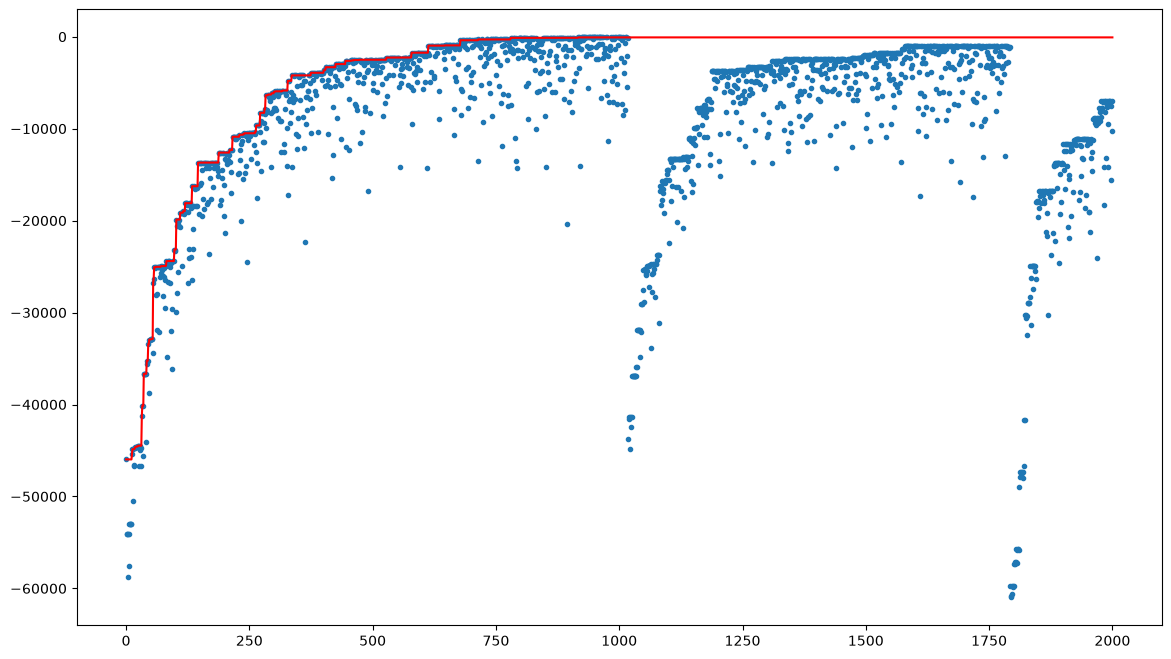

In [215]:
plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history)),
    list(accumulate(history, max)),
    color="red",
)
_ = plt.scatter(range(len(history)), history, marker=".")